In [1]:
import pandas as pd
import numpy as np
import yfinance as yf

In [2]:
ticker="TATAMOTORS.NS"

# Downloading the data

In [3]:
TATA=yf.download(ticker,start="2018-4-1",end="2025-4-11")

YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  1 of 1 completed


In [4]:
TATA.head()

Price,Close,High,Low,Open,Volume
Ticker,TATAMOTORS.NS,TATAMOTORS.NS,TATAMOTORS.NS,TATAMOTORS.NS,TATAMOTORS.NS
Date,,,,,
2018-04-02,337.056122,338.695929,330.645962,332.931750,9874486
2018-04-03,340.981750,342.373101,335.068473,336.310756,6989584
2018-04-04,353.404572,361.454569,344.112291,344.658884,27157199
2018-04-05,359.963837,370.051166,357.578630,360.361361,28886070
2018-04-06,361.852112,366.075873,354.249348,359.765071,13297051


# Plotting the data 

In [5]:
import matplotlib.pyplot as plt
from datetime import datetime
start_date=datetime(2018,4,2)
end_date=datetime(2025,4,11)

In [6]:
closing=TATA.loc[start_date:end_date,"Close"]

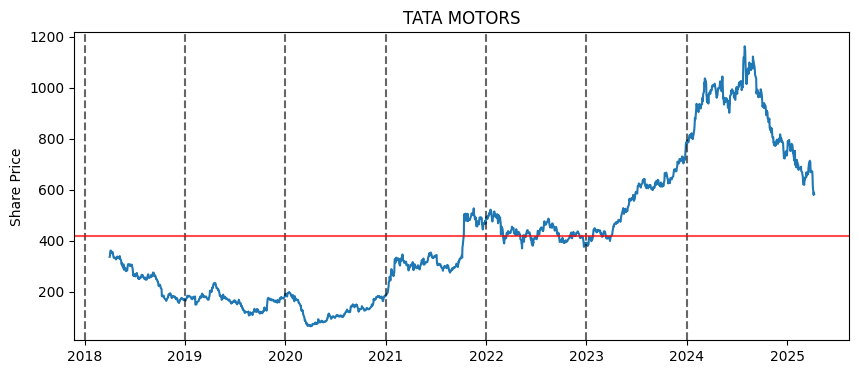

In [7]:
plt.figure(figsize=(10,4))
plt.plot(closing)
plt.title("TATA MOTORS")
plt.ylabel("Share Price")
for year in range(start_date.year,end_date.year):
    plt.axvline(pd.to_datetime(f"{year}-01-01"),linestyle="--",alpha=0.6,color="k")
plt.axhline(closing["TATAMOTORS.NS"].mean(),linestyle="-",color="r",alpha=0.7)

# Checking if the data is stationary or not

In [8]:
from statsmodels.tsa.stattools import adfuller
result=adfuller(closing.dropna())
print("ADF Statistics:", result[0])
print("p-value:", result[1])

ADF Statistics: -1.0366092866599046
p-value: 0.7396788986631576


# Trying differencing to remove trends and to make data stationary

In [9]:
closing_diff=closing.diff(5).dropna()

# Plotting the differenced the data

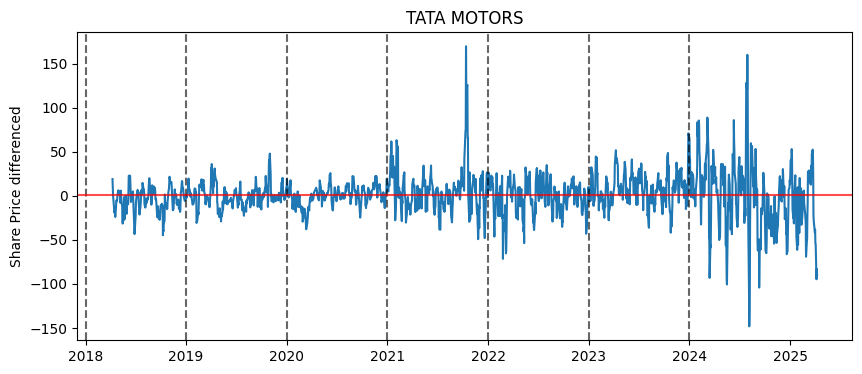

In [10]:
plt.figure(figsize=(10,4))
plt.plot(closing_diff)
plt.title("TATA MOTORS")
plt.ylabel("Share Price differenced")
for year in range(start_date.year,end_date.year):
    plt.axvline(pd.to_datetime(f"{year}-01-01"),linestyle="--",alpha=0.6,color="k")
plt.axhline(closing_diff["TATAMOTORS.NS"].mean(),linestyle="-",color="r",alpha=0.7)

# Testing the stationary of data again

In [11]:
result=adfuller(closing_diff.dropna())
print("ADF Statistics:", result[0])
print("p-value:", result[1])

ADF Statistics: -5.444856818244363
p-value: 2.7248469049096465e-06


# Importing the AutoARIMA to train the model

In [17]:
from pmdarima import auto_arima

In [42]:
model = auto_arima(closing["TATAMOTORS.NS"], 
                   seasonal=False,  # Set seasonal=True if you suspect seasonality (e.g., weekly patterns)
                   trace=True,      # To show progress of the auto_arima process
                   error_action='ignore',  
                   suppress_warnings=True, 
                   stepwise=True)   # Makes the model fitting faster

C:\Users\shiva\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\shiva\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\shiva\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\shiva\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Pyt

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=13060.327, Time=1.05 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=13058.738, Time=0.02 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=13060.205, Time=0.06 sec


C:\Users\shiva\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\shiva\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\shiva\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=13060.251, Time=0.13 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=13057.060, Time=0.03 sec


C:\Users\shiva\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\shiva\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=13061.157, Time=0.28 sec

Best model:  ARIMA(0,1,0)(0,0,0)[0]          
Total fit time: 1.579 seconds


In [43]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                 1736
Model:               SARIMAX(0, 1, 0)   Log Likelihood               -6527.530
Date:                Mon, 14 Apr 2025   AIC                          13057.060
Time:                        21:51:00   BIC                          13062.518
Sample:                             0   HQIC                         13059.078
                               - 1736                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2       108.4904      1.441     75.310      0.000     105.667     111.314
===================================================================================
Ljung-Box (L1) (Q):                   0.53   Jarque-Bera (JB):              8935.13
Prob(Q):                              0.46   Prob(JB):                         0.00
Heteroskedasticity (H):               6.49   Skew:                            -0.33
Prob(H) (two-sided):                  0.00   Kurtosis:                        14.10
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [44]:

# Forecast the next 10 days of stock prices
forecast_periods = 10
forecast = model.predict(n_periods=forecast_periods)


C:\Users\shiva\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\shiva\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
C:\Users\shiva\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


In [45]:
# Create a DataFrame for the forecasted values
forecast_dates = pd.date_range(start=TATA.index[-1] + pd.Timedelta(days=1), periods=forecast_periods, freq='D')
forecast_df = pd.DataFrame({
    'Date': forecast_dates,
    'Forecasted_Price': forecast
})
# Print the forecast DataFrame
print(forecast_df)

           Date  Forecasted_Price
1736 2025-04-10        582.900024
1737 2025-04-11        582.900024
1738 2025-04-12        582.900024
1739 2025-04-13        582.900024
1740 2025-04-14        582.900024
1741 2025-04-15        582.900024
1742 2025-04-16        582.900024
1743 2025-04-17        582.900024
1744 2025-04-18        582.900024
1745 2025-04-19        582.900024


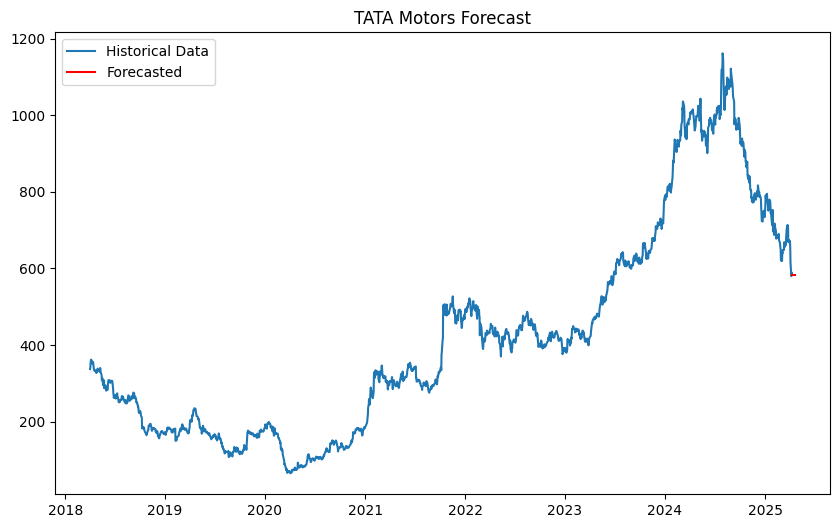

In [46]:

# Optionally, plot the original series and forecasted values
plt.figure(figsize=(10, 6))
plt.plot(TATA['Close'], label='Historical Data')
plt.plot(forecast_df['Date'], forecast_df['Forecasted_Price'], label='Forecasted', color='red')
plt.legend()
plt.title("TATA Motors Forecast")
plt.show()